### Анализ и прогнозирование спроса на такси и каршеринг

In [1]:
# Выгрузим нужные библиотеки

import pandas as pd
import folium
import json
from folium import Choropleth
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)

In [5]:
main_df = pd.read_csv('main_df.csv', sep=',')
main_df.head()


,timestamp,district_name,district_id,lat,lon,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end,temperature,precipitation,humidity,wind_speed,weather_code,rush_hour,season,is_holiday_or_weekend,quarter,station_load,number_of_stations,number_of_places,population_district_2023,population_near_metro,price_m2
0,2024-01-01 00:00:00,район Кунцево,0,55.758995,37.167845,8,4,0,0,-11.0,0.0,79,21.6,3,0,0,1,I квартал,7,2,0,135092,0.321665,289.4
1,2024-01-01 01:00:00,район Кунцево,0,55.758995,37.167845,11,11,1,1,-11.0,0.0,79,18.0,3,0,0,1,I квартал,7,2,0,135092,0.321665,289.4
2,2024-01-01 02:00:00,район Кунцево,0,55.758995,37.167845,7,7,0,0,-11.0,0.0,79,21.6,3,0,0,1,I квартал,7,2,0,135092,0.321665,289.4
3,2024-01-01 03:00:00,район Кунцево,0,55.758995,37.167845,12,8,0,0,-11.0,0.0,79,21.6,3,0,0,1,I квартал,7,2,0,135092,0.321665,289.4
4,2024-01-01 04:00:00,район Кунцево,0,55.758995,37.167845,5,6,0,0,-11.0,0.0,79,18.0,3,0,0,1,I квартал,7,2,0,135092,0.321665,289.4


In [6]:
# Открываем GeoJSON-файл
with open("data/msc_borders_clean.geojson", "r", encoding="utf-8") as f:
    msc_borders_clean = json.load(f)

### 📊 Описание данных

Датасет содержит **25** признаков, которые можно разделить на три группы: **количественные, категориальные и бинарные**.

#### 📏 Количественные признаки:
1. `timestamp`  — Метка времени, соответствующая периоду наблюдений
2. `lat` — Широта центра района  
3. `lon` — Долгота центра района  
4. `n_taxi_start` — Количество поездок на такси, начавшихся в районе  
5. `n_taxi_end` — Количество поездок на такси, завершившихся в районе  
6. `n_carsharing_start` — Количество поездок на каршеринге, начавшихся в районе  
7. `n_carsharing_end` — Количество поездок на каршеринге, завершившихся в районе  
9. `temperature` — Температура воздуха (°C) на момент наблюдений  
9. `precipitation` — Количество осадков (мм) на момент наблюдений  
10. `humidity` — Влажность воздуха (%) на момент наблюдений  
11. `wind_speed` — Скорость ветра (м/с) на момент наблюдений  
12. `station_load` — Степень загруженности метро
13. `station_load_norm` - Степень загруженности метро нормализованная
14. `number_of_stations` - Количество станций метро по районам Москвы
15. `number_of_places` — Количество популярных локаций в районе
16. `population_district_2023` — Население района на 2023 год
17. `population_near_metro_percent` — Доля населения, проживающего рядом с метро
18. `price_m2` — Средняя стоимость квадратного метра в районе

#### 🔹 Категориальные признаки:
1. `district_name` — Название района Москвы  
2. `administrative_region` — Название административного округа Москвы  
3. `weather_code` — Код погоды согласно метеоданным  
4. `quarter` — Номер квартала  
5. `season` — Сезон (зима/весна/лето/осень)  

#### ⚡ Бинарные признаки:
1. `is_holiday_or_weekend` — Признак выходного дня / праздника (0 — нет, 1 — да)  
2. `rush_hour` — Час пик (0 — нет, 1 — да)  


Посмотрим на данные - для этого напишем функцию, которая будет выводить основную информацию о датасете.

In [7]:
# Функция для вывода общей информации
def general (table):
    display(table.head())
    display(table.info())
    display('Количество пропущенных значений:',table.isna().sum())
    display('Количество нулевых значений:', (table == 0).sum())
    display('Количество дубликатов:',table.duplicated().sum())

In [8]:
general (main_df)

,timestamp,district_name,district_id,lat,lon,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end,temperature,precipitation,humidity,wind_speed,weather_code,rush_hour,season,is_holiday_or_weekend,quarter,station_load,number_of_stations,number_of_places,population_district_2023,population_near_metro,price_m2
0,2024-01-01 00:00:00,район Кунцево,0,55.758995,37.167845,8,4,0,0,-11.0,0.0,79,21.6,3,0,0,1,I квартал,7,2,0,135092,0.321665,289.4
1,2024-01-01 01:00:00,район Кунцево,0,55.758995,37.167845,11,11,1,1,-11.0,0.0,79,18.0,3,0,0,1,I квартал,7,2,0,135092,0.321665,289.4
2,2024-01-01 02:00:00,район Кунцево,0,55.758995,37.167845,7,7,0,0,-11.0,0.0,79,21.6,3,0,0,1,I квартал,7,2,0,135092,0.321665,289.4
3,2024-01-01 03:00:00,район Кунцево,0,55.758995,37.167845,12,8,0,0,-11.0,0.0,79,21.6,3,0,0,1,I квартал,7,2,0,135092,0.321665,289.4
4,2024-01-01 04:00:00,район Кунцево,0,55.758995,37.167845,5,6,0,0,-11.0,0.0,79,18.0,3,0,0,1,I квартал,7,2,0,135092,0.321665,289.4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1229760 entries, 0 to 1229759
Data columns (total 24 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   timestamp                 1229760 non-null  object 
 1   district_name             1229760 non-null  object 
 2   district_id               1229760 non-null  int64  
 3   lat                       1229760 non-null  float64
 4   lon                       1229760 non-null  float64
 5   n_taxi_start              1229760 non-null  int64  
 6   n_taxi_end                1229760 non-null  int64  
 7   n_carsharing_start        1229760 non-null  int64  
 8   n_carsharing_end          1229760 non-null  int64  
 9   temperature               1229760 non-null  float64
 10  precipitation             1229760 non-null  float64
 11  humidity                  1229760 non-null  int64  
 12  wind_speed                1229760 non-null  float64
 13  weather_code              1

None

'Количество пропущенных значений:'

,0
timestamp,0
district_name,0
district_id,0
lat,0
lon,0
n_taxi_start,0
n_taxi_end,0
n_carsharing_start,0
n_carsharing_end,0
temperature,0


'Количество нулевых значений:'

,0
timestamp,0
district_name,0
district_id,8784
lat,0
lon,0
n_taxi_start,61216
n_taxi_end,59797
n_carsharing_start,88592
n_carsharing_end,85108
temperature,21283


'Количество дубликатов:'

np.int64(0)

#### Обработка типов данных

In [9]:
# Преобрузем время поездки из Object в datetime
main_df['timestamp'] = pd.to_datetime(main_df['timestamp'])
# Квартал и сезон приведем к категориальныму типу
main_df['quarter'] = main_df['quarter'].astype('category')
main_df['season'] = main_df['season'].astype('category')


#### Обработка пропусков и нулевых значений

Так как датасет содержит большое количество столбцов,воспринимать информацию в виде таблицы не совсем удобно. Мы видим из общей информации,что пропущенных значений нет, однако, есть много нулевых - попробуем их визуализировать.

<ipython-input-10-560d6aef85a0>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=zero_percent.index, y=zero_percent.values, palette='light:r')


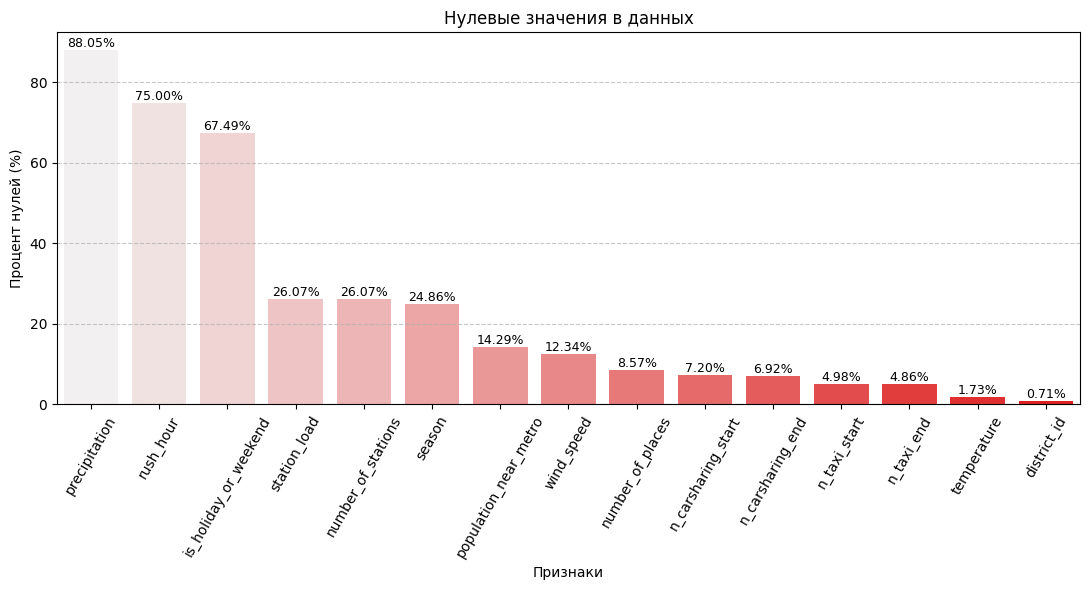

In [10]:
# Рассчитываем процент нулевых значений для каждого столбца
zero_percent = (main_df == 0).mean() * 100

# Оставляем только те столбцы, где есть хотя бы одно нулевое значение
zero_percent = zero_percent[zero_percent > 0].sort_values(ascending=False)

# Строим график
plt.figure(figsize=(11, 6))
ax = sns.barplot(x=zero_percent.index, y=zero_percent.values, palette='light:r')

plt.xticks(rotation=60, fontsize=10)
plt.title('Нулевые значения в данных', fontsize=12)
plt.ylabel('Процент нулей (%)', fontsize=10)
plt.xlabel('Признаки', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Добавляем подписи с процентом над столбцами
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',  # Форматируем числа с двумя знаками после запятой
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, color='black', rotation=0)

plt.tight_layout()
plt.show()

Смущает большое количество нулей в столбце с осадками.  Посмотрим, как распределено количество осадков по месяцам и сравним с информацией из открытых источников.

<ipython-input-11-b489998fe7dd>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_precipitation.index, y=monthly_precipitation.values, palette='Blues_r')


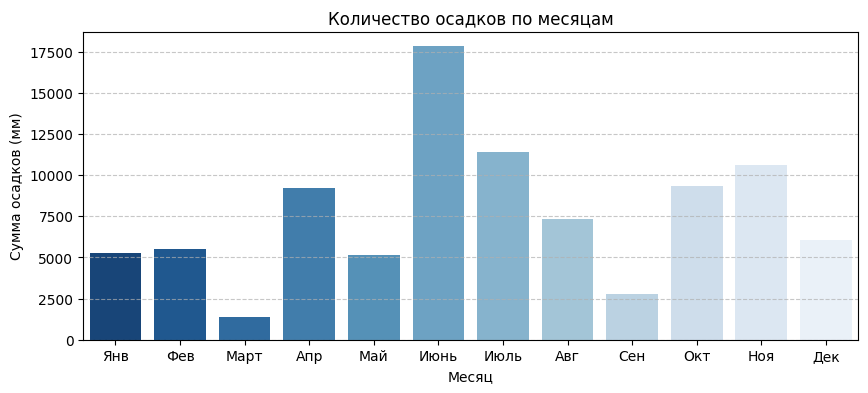

In [11]:
# Делаем дополнительный столбец с месяцем
main_df['month'] = main_df['timestamp'].dt.month.astype('int64')

# Группируем данные по месяцам и суммируем осадки
monthly_precipitation = main_df.groupby('month')['precipitation'].sum()

# Настраиваем график
plt.figure(figsize=(10, 4))
sns.barplot(x=monthly_precipitation.index, y=monthly_precipitation.values, palette='Blues_r')

# Подписываем оси
plt.xlabel('Месяц')
plt.ylabel('Сумма осадков (мм)')
plt.title('Количество осадков по месяцам')

# Улучшаем читаемость
plt.xticks(ticks=range(12), labels=['Янв', 'Фев', 'Март', 'Апр', 'Май', 'Июнь',
                                     'Июль', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Согласно новостным источникам, 2024 год стал самым засушливым в Москве за всю историю метеонаблюдений. В частности, в марте выпало 24% от нормы осадков, а в сентябре - лишь 17% от нормы (http://www.pogodaiklimat.ru/monitor.php?id=27612&month=9&year=2024).
Этим мы и можем объяснить распределение, полученное на диаграмме выше, а  также количество нулевых значений в столбце с осадками - они соответствуют информации о погоде метеорологических станций Москвы.

Нулевые значения в бинарных признаках и категорильном признаке сезона также является нормальным,0 обозначены рабочие дни, непиковые значения дня и зимнее время года.

In [12]:
print("Уникальные значения 'is_holiday_or_weekend':", main_df['is_holiday_or_weekend'].unique())
print("Уникальные значения 'rush_hour':", main_df['rush_hour'].unique())
print("Уникальные значения 'season':", main_df['season'].unique())


Уникальные значения 'is_holiday_or_weekend': [1 0]
Уникальные значения 'rush_hour': [0 1 2]
Уникальные значения 'season': [0, 1, 2, 3]
Categories (4, int64): [0, 1, 2, 3]


Остальные нулевые значения также вполне допустимы (например, отсутствие поездок в некоторые часы на такси или каршеринге) и составляют небольшой процент.

### 🔍 Первые выводы по общей информации о данных

#### 📌 Пропуски в данных
- Пропущенные значения **отсутствуют**, что упрощает обработку.

#### 📊 Нулевые значения
**Есть признаки,содержащие нулевые значения:**
- 🚖 `n_taxi_start` (1 584) и `n_taxi_end` (1 201) — связано с тем в некоторые часы **не было поездок**.
- 🚗 `n_carsharing_start` (18 375) и `n_carsharing_end` (17 448) — также,как и с такси - в определенное время поездок не было.
- 🌧 `precipitation` (1 018 979), 💨 `wind_speed` (146 705) — объяснется особенностью погодных условий в рассматриваемый период.
- ⏳ `rush_hour` (867 240) — категориальный признак, большая часть значений **равна 0** - много поездок **вне пиковых часов**.
- 🚇 `population_near_metro` (140 160) —  **есть районы без станций метро**.
- 🍂 `season`(285 120) — поездки в  **зимний период**

#### 🔁 Дубликаты
- Полных **дубликатов строк нет**, что хорошо для анализа.


### Описательные статистики

Теперь с помощью функции describe посмотрим на распределение данных, их описательные статистики и возможные выбросы.

In [13]:
main_df.describe()

,timestamp,district_id,lat,lon,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end,temperature,precipitation,humidity,wind_speed,weather_code,rush_hour,is_holiday_or_weekend,station_load,number_of_stations,number_of_places,population_district_2023,population_near_metro,price_m2,month
count,1229760,1.229760e+06,1.229760e+06,1.229760e+06,1.229760e+06,1.229760e+06,1.229760e+06,1.229760e+06,1.229760e+06,1.229760e+06,1.229760e+06,1.229760e+06,1.229760e+06,1.229760e+06,1.229760e+06,1.229760e+06,1.229760e+06,1.229760e+06,1.229760e+06,1.229760e+06,1.229760e+06,1.229760e+06
mean,2024-07-01 23:29:59.999998208,6.950000e+01,5.574668e+01,3.756430e+01,2.534229e+02,2.523727e+02,3.135703e+01,3.134476e+01,7.848870e+00,7.470417e-02,7.326821e+01,7.308974e+00,4.315896e+00,3.750000e-01,3.251366e-01,5.832266e+00,1.921468e+00,7.662143e+01,9.254039e+04,4.144656e-01,2.679164e+02,6.513661e+00
min,2024-01-01 00:00:00,0.000000e+00,5.527237e+01,3.695810e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-3.140000e+01,0.000000e+00,2.000000e+01,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.113000e+03,0.000000e+00,1.585000e+02,1.000000e+00
25%,2024-04-01 11:45:00,3.475000e+01,5.567345e+01,3.747485e+01,8.100000e+01,8.500000e+01,9.000000e+00,9.000000e+00,-3.000000e-01,0.000000e+00,6.100000e+01,3.600000e+00,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.900000e+01,6.533875e+04,2.316371e-01,2.274000e+02,4.000000e+00
50%,2024-07-01 23:30:00,6.950000e+01,5.575899e+01,3.758873e+01,1.990000e+02,1.980000e+02,2.600000e+01,2.600000e+01,7.500000e+00,0.000000e+00,7.700000e+01,5.500000e+00,3.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,2.000000e+00,3.400000e+01,9.566000e+04,4.158630e-01,2.513500e+02,7.000000e+00
75%,2024-10-01 11:15:00,1.042500e+02,5.583086e+01,3.768655e+01,3.380000e+02,3.240000e+02,4.600000e+01,4.500000e+01,1.750000e+01,0.000000e+00,8.700000e+01,1.080000e+01,4.000000e+00,2.500000e-01,1.000000e+00,8.000000e+00,3.000000e+00,8.350000e+01,1.169602e+05,6.050128e-01,2.893250e+02,1.000000e+01
max,2024-12-31 23:00:00,1.390000e+02,5.600280e+01,3.793678e+01,1.960600e+04,2.326600e+04,6.740000e+02,8.540000e+02,3.500000e+01,1.190000e+01,1.000000e+02,4.700000e+01,2.500000e+01,2.000000e+00,1.000000e+00,6.200000e+01,1.400000e+01,3.000000e+02,2.550440e+05,9.999639e-01,5.184000e+02,1.200000e+01
std,NaN,4.041350e+01,1.237636e-01,1.895366e-01,2.597526e+02,2.690818e+02,2.821211e+01,2.820368e+01,1.133071e+01,3.833450e-01,1.738131e+01,6.654883e+00,4.524644e+00,6.959708e-01,4.684261e-01,6.637859e+00,1.980487e+00,9.371583e+01,4.514886e+04,2.760294e-01,6.484551e+01,3.451235e+00


Формат чисел не удобен для анализа - напишем функцию, чтобы выводить статистики в читаемом виде.

In [14]:
def format_describe(df):
    """
    Форматирует числовые значения в describe(), добавляя разделители тысяч и округляя до 0 знаков после запятой.
    """
    describe_df = df.describe()  # Получаем статистику по данным

    # Определяем числовые столбцы
    numeric_cols = [col for col in describe_df.columns if df[col].dtype in ['int64', 'float64']]

    # Применяем форматирование только к числовым столбцам
    describe_df[numeric_cols] = describe_df[numeric_cols].applymap(lambda x: f"{x:,.0f}" if pd.notna(x) else "NaN")

    return describe_df

format_describe(main_df)  # Выводим отформатированное describe()

<ipython-input-14-4cb939b8bd3e>:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  describe_df[numeric_cols] = describe_df[numeric_cols].applymap(lambda x: f"{x:,.0f}" if pd.notna(x) else "NaN")


,timestamp,district_id,lat,lon,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end,temperature,precipitation,humidity,wind_speed,weather_code,rush_hour,is_holiday_or_weekend,station_load,number_of_stations,number_of_places,population_district_2023,population_near_metro,price_m2,month
count,1229760,"1,229,760","1,229,760","1,229,760","1,229,760","1,229,760","1,229,760","1,229,760","1,229,760","1,229,760","1,229,760","1,229,760","1,229,760","1,229,760","1,229,760","1,229,760","1,229,760","1,229,760","1,229,760","1,229,760","1,229,760","1,229,760"
mean,2024-07-01 23:29:59.999998208,70,56,38,253,252,31,31,8,0,73,7,4,0,0,6,2,77,"92,540",0,268,7
min,2024-01-01 00:00:00,0,55,37,0,0,0,0,-31,0,20,0,1,0,0,0,0,0,"9,113",0,158,1
25%,2024-04-01 11:45:00,35,56,37,81,85,9,9,-0,0,61,4,2,0,0,0,0,19,"65,339",0,227,4
50%,2024-07-01 23:30:00,70,56,38,199,198,26,26,8,0,77,6,3,0,0,4,2,34,"95,660",0,251,7
75%,2024-10-01 11:15:00,104,56,38,338,324,46,45,18,0,87,11,4,0,1,8,3,84,"116,960",1,289,10
max,2024-12-31 23:00:00,139,56,38,"19,606","23,266",674,854,35,12,100,47,25,2,1,62,14,300,"255,044",1,518,12
std,NaN,40,0,0,260,269,28,28,11,0,17,7,5,1,0,7,2,94,"45,149",0,65,3


#### 📊 Анализ описательных статистик

##### Выбросы и аномалии:
- **Отрицательных значений для количества поездок (`n_taxi_start`, `n_taxi_end`, `n_carsharing_start`, `n_carsharing_end`) нет**, что корректно.  
- **Максимальные значения поездок (такси и каршеринг) сильно превышают среднее**, что указывает на возможные пики спроса в отдельные часы - нужно проверить.  
- **Осадки (`precipitation`), влажность (`humidity`),температура (`temperature`),  в пределах физически возможных значений.**  
- Макисмальная **скорость ветра** (`wind_speed`) достигает 47 м/с - что соответствует почти урагану, **нужно проверить этот признак.**  


Проверим строки, для которых скорость ветра слишком высокая либо слишком низкая.

In [15]:
Q1 = main_df['wind_speed'].quantile(0.25)
Q3 = main_df['wind_speed'].quantile(0.75)
IQR = Q3 - Q1

# Границы выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
#
outliers = main_df[(main_df['wind_speed'] < lower_bound) | (main_df['wind_speed'] > upper_bound)]

In [16]:
print(f"Количество выбросов в wind_speed: {len(outliers)}")
print(f"% Выбросов в wind_speed: {round((len(outliers)/len(main_df))*100,2)}")

Количество выбросов в wind_speed: 42899
% Выбросов в wind_speed: 3.49


Процент таких значений невысок - пока можем оставить их как есть, так как в дальнейшем экстремумы могут помочь в распознавании “аномальных” сценариев поездок (шторм — меньше такси, например).

Таким же способом проверим данные о количестве поездок.

In [17]:
Q1 = main_df['n_taxi_start'].quantile(0.25)
Q3 = main_df['n_taxi_start'].quantile(0.75)
IQR = Q3 - Q1

# Границы выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
#
outliers = main_df[(main_df['n_taxi_start'] < lower_bound) | (main_df['n_taxi_start'] > upper_bound)]

In [18]:
print(f"Количество выбросов в n_taxi_start: {len(outliers)}")
print(f"% Выбросов в n_taxi_start: {round((len(outliers)/len(main_df))*100,2)}")

Количество выбросов в n_taxi_start: 58553
% Выбросов в n_taxi_start: 4.76


Процент таких значений также невелик,при этом они могут отражать реальные события и быть индикатором интересных тенденций, а не ошибок в данных, поэтому оставим их без изменений.

### Корреляция стоимости жилья и спроса на такси

#### Цены на недвижимость по районам Москвы - карта

Посмотрим, как распределены цены на недвижимость в зависимости от районов - для наглядности построим карту (хороплет).

In [19]:

msc_estate_price_final = pd.read_csv('data/msc_estate_price_final.csv',sep=',')

In [20]:
# Преобразуем в словарь для быстрого поиска цены по названию района
price_dict = dict(zip(msc_estate_price_final['district_name'], msc_estate_price_final['price_m2']))

# Добавляем стоимость жилья в свойства районов GeoJSON
for feature in msc_borders_clean['features']:
    district_name = feature['properties']['name']
    feature['properties']['price_m2'] = price_dict.get(district_name)

# Создаем карту Москвы
moscow_lat, moscow_lng = 55.751244, 37.618423
m = folium.Map(location=[moscow_lat, moscow_lng], zoom_start=10, tiles='Cartodb Positron')

# Добавляем хороплет-карту с ценами на жилье
choropleth = Choropleth(
    geo_data=msc_borders_clean,
    data=price_dict,
    columns=['district_name', 'price_m2'],
    key_on='feature.properties.name',  # Связываем с name в GeoJSON
    fill_color='YlOrRd',  # Цветовая гамма (желтый -> оранжевый -> красный)
    fill_opacity=0.8,
    line_opacity=0.2,
    legend_name='Средняя стоимость жилья (тыс. руб. за м²)'
).add_to(m)

# Добавляем всплывающую информацию при наведении на район
folium.GeoJson(
    msc_borders_clean,
    style_function=lambda feature: {
        "fillColor": "transparent",  # Не перезаписываем цвет
        "color": "black",
        "weight": 1,
        "fillOpacity": 0
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["name", "price_m2"],
        aliases=["Район", "Цена за м² (тыс. руб.)"],
        localize=True,
        sticky=False
    )
).add_to(m)

from branca.element import Element
# CSS для скрытия надписи Leaflet
css = """
<style>
.leaflet-control-attribution {
    display: none !important;
}
</style>
"""
# Добавляем стиль на карту
m.get_root().html.add_child(Element(css))

# Отображаем карту
m

Как мы видим - самые дорогие районы сосредоточены в центре Москвы. Дополнительно сделаем диаграмму с топ-10 райнов по ценам.

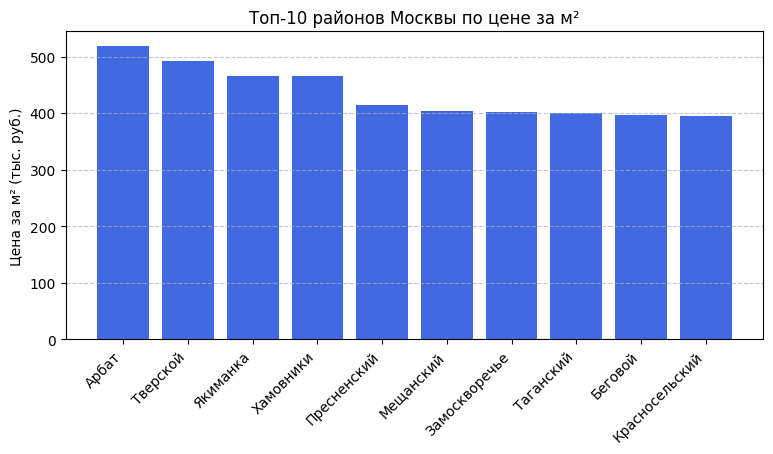

In [21]:
# Сортируем и выбираем топ-10 районов
top_10 = msc_estate_price_final.nlargest(10, "price_m2")

# Убираем слово "район" в топ-10
top_10["district_name"] = top_10["district_name"].str.replace(r"\bрайон\b", "", regex=True).str.strip()

# Строим вертикальный график
plt.figure(figsize=(9, 4))
plt.bar(top_10["district_name"], top_10["price_m2"], color="royalblue")
plt.ylabel("Цена за м² (тыс. руб.)")
plt.xticks(rotation=45, ha="right")  # Поворачиваем подписи для читаемости
plt.title("Топ-10 районов Москвы по цене за м²")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

#### Корреляция цены недвижимости и числа поездок на такси

Для оценки корреляции цены недвижимости и числа поездок введём дополнительный признак — количество поездок на человека. Это позволит нормализовать данные, исключив влияние плотности населения: более крупные районы могут демонстрировать большее количество поездок не из-за высокого уровня жизни, а просто потому что там проживает больше людей.

Также, рассмотрим корреляцию в разные временные промежутки: рабочие дни и выходные, часы пик и внепиковые часы.Такое разделение поможет понять, как в каждом временном промежутке цена на недвижимость может оказывать влияние на выбор такси. Например, в районах с высокой стоимостью жилья может быть выше спрос на такси и в рабочие дни, и в выходные, поскольку люди с высокой покупательной способностью имеют более высокую потребность в комфортных поездках.

In [22]:
# Сделаем агрегационные функции для n_taxi_start и end для разных временных промежутков
agg_funcs = {
    'total_per_person': lambda x, col: (x[col].sum() / x['population_district_2023'].iloc[0]),
    'offpeak_per_person': lambda x, col: (x[x['rush_hour'] == 0][col].sum() / x['population_district_2023'].iloc[0]),
    'rushhour_per_person': lambda x, col: (x[x['rush_hour'] == 1][col].sum() / x['population_district_2023'].iloc[0]),
    'weekend_per_person': lambda x, col: (x[x['is_holiday_or_weekend'] == 1][col].sum() / x['population_district_2023'].iloc[0]),
    'weekday_per_person': lambda x, col: (x[x['is_holiday_or_weekend'] == 0][col].sum() / x['population_district_2023'].iloc[0]),
    'price_m2': lambda x: x['price_m2'].iloc[0]
}

# Применяем агрегацию для start и end
def aggregate_data(df, col):
    return pd.Series({k: f(df, col) if k != 'price_m2' else f(df) for k, f in agg_funcs.items()})

# Применяем агрегацию для обеих колонок: start и end
summary_start = main_df.groupby('district_name').apply(lambda df: aggregate_data(df, 'n_taxi_start'))
summary_end = main_df.groupby('district_name').apply(lambda df: aggregate_data(df, 'n_taxi_end'))

# Соединяем данные
summary = pd.concat([summary_start, summary_end], axis=1, keys=['start', 'end'])

# Выводим таблицу
# Теперь каждому району соответствует количество поездок на человека в целом за год, в выходные,рабочие дни, пиковые и непиковые часы дня
print(summary.head(5))

# Корреляции с ценой для start и end поездок
correlations_start = summary['start'].drop(columns='price_m2').corrwith(summary['start']['price_m2']).to_frame().T
correlations_end = summary['end'].drop(columns='price_m2').corrwith(summary['end']['price_m2']).to_frame().T

# Переименовываем индексы для ясности
correlations_start.index = ['n_taxi_start']
correlations_end.index = ['n_taxi__end']

# Объединяем корреляции для start и end в одну таблицу
correlations_all = pd.concat([correlations_start, correlations_end])

# Выводим результат корреляции
print("\n📈 Общие корреляции:\n", correlations_all)



<ipython-input-22-8302f33bdd93>:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_start = main_df.groupby('district_name').apply(lambda df: aggregate_data(df, 'n_taxi_start'))


                               start                                                                                                    end                                                                                      
                    total_per_person offpeak_per_person rushhour_per_person weekend_per_person weekday_per_person price_m2 total_per_person offpeak_per_person rushhour_per_person weekend_per_person weekday_per_person price_m2
district_name                                                                                                                                                                                                                    
Академический район        19.755374          13.104299            3.260867           5.353667          14.401707    317.4        18.543768          12.889652            2.693015           5.176620          13.367149    317.4
Алексеевский район         38.706062          26.084469            6.277566          11.315780  

<ipython-input-22-8302f33bdd93>:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_end = main_df.groupby('district_name').apply(lambda df: aggregate_data(df, 'n_taxi_end'))


Для start (0.484) и end (0.444) поездок наблюдается умеренная положительная корреляция с ценой на недвижимость, то есть в более дорогих районах люди чаще используют услуги такси.

Корреляция для начала поездок усиливается во внепиковые часы  (0.502), и значительно ослабевает в пиковые (0.295), связанные с началом и окончанием рабочего дня. Скорее всего это связано с тем, что в более дорогих, центральных районах люди предпочитают использовать альтернативные виды транспорта в часы пик, но в то же время, могут позволить себе больше поездок, не связанных с работой (например, в выходные (0.491) или для личных нужд).

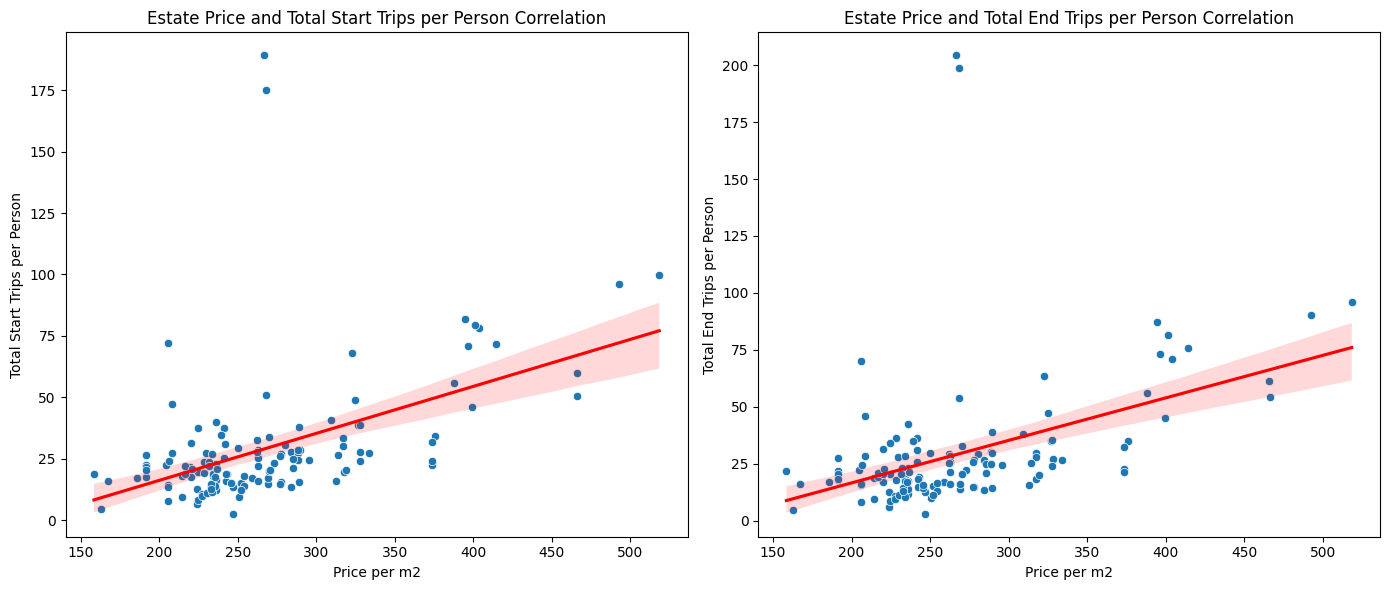

In [23]:
# Для наглядности построим графики корреляции для n_taxi_start и end в целом за год

# Размер графиков
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График для n_taxi_start
sns.scatterplot(data=summary['start'], x='price_m2', y='total_per_person', ax=axes[0])
sns.regplot(data=summary['start'], x='price_m2', y='total_per_person', scatter=False, color='r', ax=axes[0])

# Добавляем заголовок и подписи для первого графика
axes[0].set_title('Estate Price and Total Start Trips per Person Correlation')
axes[0].set_xlabel('Price per m2')
axes[0].set_ylabel('Total Start Trips per Person')

# График для n_taxi_end
sns.scatterplot(data=summary['end'], x='price_m2', y='total_per_person', ax=axes[1])
sns.regplot(data=summary['end'], x='price_m2', y='total_per_person', scatter=False, color='r', ax=axes[1])

# Добавляем заголовок и подписи для второго графика
axes[1].set_title('Estate Price and Total End Trips per Person Correlation')
axes[1].set_xlabel('Price per m2')
axes[1].set_ylabel('Total End Trips per Person')

# Показываем графики
plt.tight_layout()
plt.show()


График для начала поездок (n_taxi_start):
- Наклон линии тренда положительный: чем выше цена за квадратный метр, тем больше поездок на человека в целом. Это свидетельствует о том, что в более дорогих районах люди, вероятно, чаще используют такси, возможно, из-за более высокого дохода и более гибких рабочих графиков. Однако рассеяние точек довольно широкое, особенно для районов с низкими ценами, что указывает на отсутствие строгой зависимости и возможное влияние других факторов, таких как плотность населения или доступность альтернативных транспортных средств.

График для окончания поездок (n_taxi_end):
- Наклон линии тренда также положительный, но менее выраженный, чем для начала поездок. В более дорогих районах люди, вероятно, чаще используют такси и для возвращения домой, хотя зависимость менее выражена. Рассеяние точек для конечных поездок тоже довольно широкое, что подтверждает более слабую корреляцию по сравнению с начальными поездками.

В целом, оба графика подтверждают, что в более дорогих районах наблюдается тенденция к большему количеству поездок на такси, но эта зависимость имеет умеренный характер и зависит от многих факторов.

#### Корреляция цены недвижимости и числа поездок на каршеринге

Каршеринг чаще используют для личных поездок, путешествий, отдыха, а также для коротких поездок по городу. Люди могут выбирать каршеринг для нерабочих поездок в выходные дни или летом, когда они чаще путешествуют, поэтому помимо общей корреляции, дополнительно посчитаем коэффициенты по сезонам и признаку выходной/ не выходной.

In [24]:
# Агрегационные функции для каршеринга, с учетом сезона и выходных
agg_funcs_carsharing = {
    'total_per_person': lambda x, col: (x[col].sum() / x['population_district_2023'].iloc[0]),
    'winter': lambda x, col: (x[x['season'] == 0][col].sum() / x['population_district_2023'].iloc[0]),
    'spring': lambda x, col: (x[x['season'] == 1][col].sum() / x['population_district_2023'].iloc[0]),
    'summer': lambda x, col: (x[x['season'] == 2][col].sum() / x['population_district_2023'].iloc[0]),
    'autumn': lambda x, col: (x[x['season'] == 3][col].sum() / x['population_district_2023'].iloc[0]),
    'isweekend': lambda x, col: (x[x['is_holiday_or_weekend'] == 1][col].sum() / x['population_district_2023'].iloc[0]),
    'notweekend': lambda x, col: (x[x['is_holiday_or_weekend'] == 0][col].sum() / x['population_district_2023'].iloc[0]),
    'price_m2': lambda x: x['price_m2'].iloc[0]
}

# Функция для start и end
def aggregate_carsharing_data(df, col):
    return pd.Series({k: f(df, col) if k != 'price_m2' else f(df) for k, f in agg_funcs_carsharing.items()})

# Применяем агрегацию для start и end
summary_carsharing_start = main_df.groupby('district_name').apply(lambda df: aggregate_carsharing_data(df, 'n_carsharing_start'))
summary_carsharing_end = main_df.groupby('district_name').apply(lambda df: aggregate_carsharing_data(df, 'n_carsharing_end'))

# Соединяем данные
summary_carsharing = pd.concat([summary_carsharing_start, summary_carsharing_end], axis=1, keys=['start', 'end'])

# Выводим таблицу
print(summary_carsharing.head(5))

# Корреляции с ценой для каршеринг start и end
correlations_carsharing_start = summary_carsharing['start'].drop(columns='price_m2').corrwith(summary_carsharing['start']['price_m2']).to_frame().T
correlations_carsharing_end = summary_carsharing['end'].drop(columns='price_m2').corrwith(summary_carsharing['end']['price_m2']).to_frame().T

# Переименовываем индексы
correlations_carsharing_start.index = ['n_carsharing_start']
correlations_carsharing_end.index = ['n_carsharing_end']

# Объединяем корреляции carsharing start и end в одну таблицу
correlations_carsharing_all = pd.concat([correlations_carsharing_start, correlations_carsharing_end])

# Выводим результат корреляции
print("\n📈 Общие корреляции для carsharing:\n", correlations_carsharing_all)


<ipython-input-24-7b7cd18f5c96>:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_carsharing_start = main_df.groupby('district_name').apply(lambda df: aggregate_carsharing_data(df, 'n_carsharing_start'))


                               start                                                                                    end                                                                      
                    total_per_person    winter    spring    summer    autumn isweekend notweekend price_m2 total_per_person    winter    spring    summer    autumn isweekend notweekend price_m2
district_name                                                                                                                                                                                    
Академический район         2.357101  0.538078  0.584683  0.603932  0.630408  0.730811   1.626290    317.4         2.243908  0.512960  0.556285  0.571945  0.602719  0.696612   1.547297    317.4
Алексеевский район          5.138084  1.129617  1.312031  1.372990  1.323446  1.760188   3.377896    326.9         4.669603  1.041246  1.186231  1.235399  1.206726  1.580925   3.088677    326.9
Алтуфьевский район          1.

<ipython-input-24-7b7cd18f5c96>:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_carsharing_end = main_df.groupby('district_name').apply(lambda df: aggregate_carsharing_data(df, 'n_carsharing_end'))


Корреляция между ценой недвижимости и количеством поездок на каршеринге есть, но она умеренная: коэффициенты для старта и окончания поездок находятся в диапазоне от 0.31 до 0.43.
Связь несколько сильнее для завершения поездок, что может быть связано с размещением каршеринговых стоянок в более дорогих районах.
По сезонам корреляция усиливается в теплые времена года - летом и весной.
В будние дни связь выше, чем в выходные, что объясняется большей деловой активностью в дорогих районах в рабочие дни.
В целом, цена недвижимости влияет на использование каршеринга, но не является  единственным определяющим фактором.

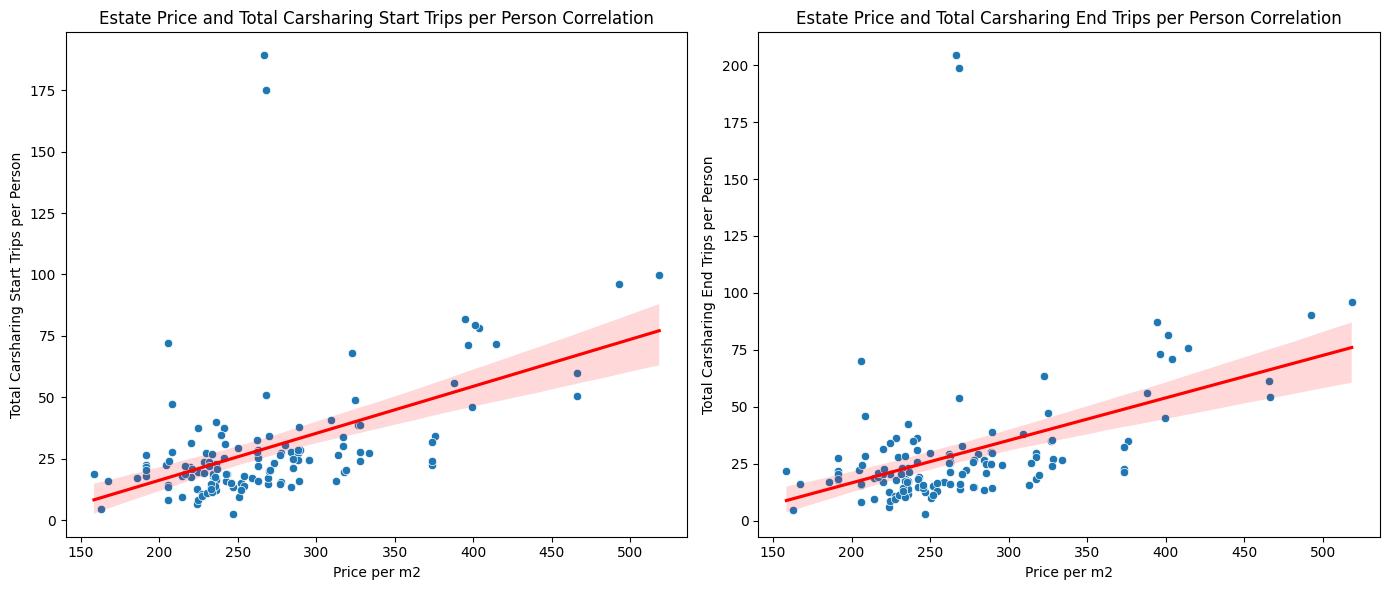

In [25]:
# Функция для построения графиков корреляции для каршеринга
def plot_carsharing_correlation(summary):
    # Размер гарфиков
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # График для n_carsharing_start
    sns.scatterplot(data=summary['start'], x='price_m2', y='total_per_person', ax=axes[0])
    sns.regplot(data=summary['start'], x='price_m2', y='total_per_person', scatter=False, color='r', ax=axes[0])

    # Добавляем заголовок и подписи для первого графика
    axes[0].set_title('Estate Price and Total Carsharing Start Trips per Person Correlation')
    axes[0].set_xlabel('Price per m2')
    axes[0].set_ylabel('Total Carsharing Start Trips per Person')

    # График для n_carsharing_end
    sns.scatterplot(data=summary['end'], x='price_m2', y='total_per_person', ax=axes[1])
    sns.regplot(data=summary['end'], x='price_m2', y='total_per_person', scatter=False, color='r', ax=axes[1])

    # Добавляем заголовок и подписи для второго графика
    axes[1].set_title('Estate Price and Total Carsharing End Trips per Person Correlation')
    axes[1].set_xlabel('Price per m2')
    axes[1].set_ylabel('Total Carsharing End Trips per Person')

    # Показываем графики
    plt.tight_layout()
    plt.show()

# Применяем функцию для построения графиков
plot_carsharing_correlation(summary)


Линия тренда на обоих графиках имеет умеренный положительный наклон, что подтверждает наличие связи между ростом цены недвижимости и увеличением количества поездок на человека.
Точек на графиках довольно много и разброс значительный, особенно в районах с более низкими ценами — это указывает на наличие других факторов, влияющих на использование каршеринга. В целом связь слабее, чем в такси.

#### Количество поездок в зависимости от времени

Посмотрим,как количество поездок распределено во времени - в зависимости от сезона,месяца,дня недели и времени суток.Перед этим дополнительно добавим необходимые столбцы к основной таблице

In [26]:
# Убедимся, что timestamp в правильном формате
main_df['timestamp'] = pd.to_datetime(main_df['timestamp'])

# Создаем дополнительные столбцы для анализа
main_df['day_of_week'] = main_df['timestamp'].dt.dayofweek  # День недели (0 - Понедельник, 6 - Воскресенье)
main_df['hour_of_day'] = main_df['timestamp'].dt.hour  # Часы суток
main_df['month'] = main_df['timestamp'].dt.month  # Месяц
main_df['season'] = main_df['month'].apply(lambda x: 'Зима' if x in [12, 1, 2] else
                                            ('Весна' if x in [3, 4, 5] else
                                             ('Лето' if x in [6, 7, 8] else 'Осень')))  # Сезон


In [27]:
# Подсчитываем количество поездок по сезонам
rides_by_season = main_df.groupby('season')['n_taxi_start'].sum().reset_index()
print(rides_by_season)

# Подсчитываем количество поездок по месяцам
rides_by_month = main_df.groupby('month')['n_taxi_start'].sum().reset_index()
rides_by_month['season'] = main_df.groupby('month')['season'].first().values # к таблице с месяцами также добавим время года
print(rides_by_month.head())

# Подсчитываем количество поездок по дням недели
rides_by_day = main_df.groupby('day_of_week')['n_taxi_start'].sum().reset_index()
print(rides_by_day.head())

# Подсчитываем количество поездок по времени суток
rides_by_hour = main_df.groupby('hour_of_day')['n_taxi_start'].sum().reset_index()
print(rides_by_hour.head())

  season  n_taxi_start
0  Весна      81707874
1   Зима      74821750
2   Лето      78214671
3  Осень      76905044
   month  n_taxi_start season
0      1      24680714   Зима
1      2      22832199   Зима
2      3      28722230  Весна
3      4      26365254  Весна
4      5      26620390  Весна
   day_of_week  n_taxi_start
0            0      42245509
1            1      43045090
2            2      46426298
3            3      46350727
4            4      48565529
   hour_of_day  n_taxi_start
0            0       9495979
1            1       7213699
2            2       5045240
3            3       3678220
4            4       3223305


Данные подготовлены - теперь приступим к визуализации

<ipython-input-28-7be7bbae1bb7>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-28-7be7bbae1bb7>:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-28-7be7bbae1bb7>:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])


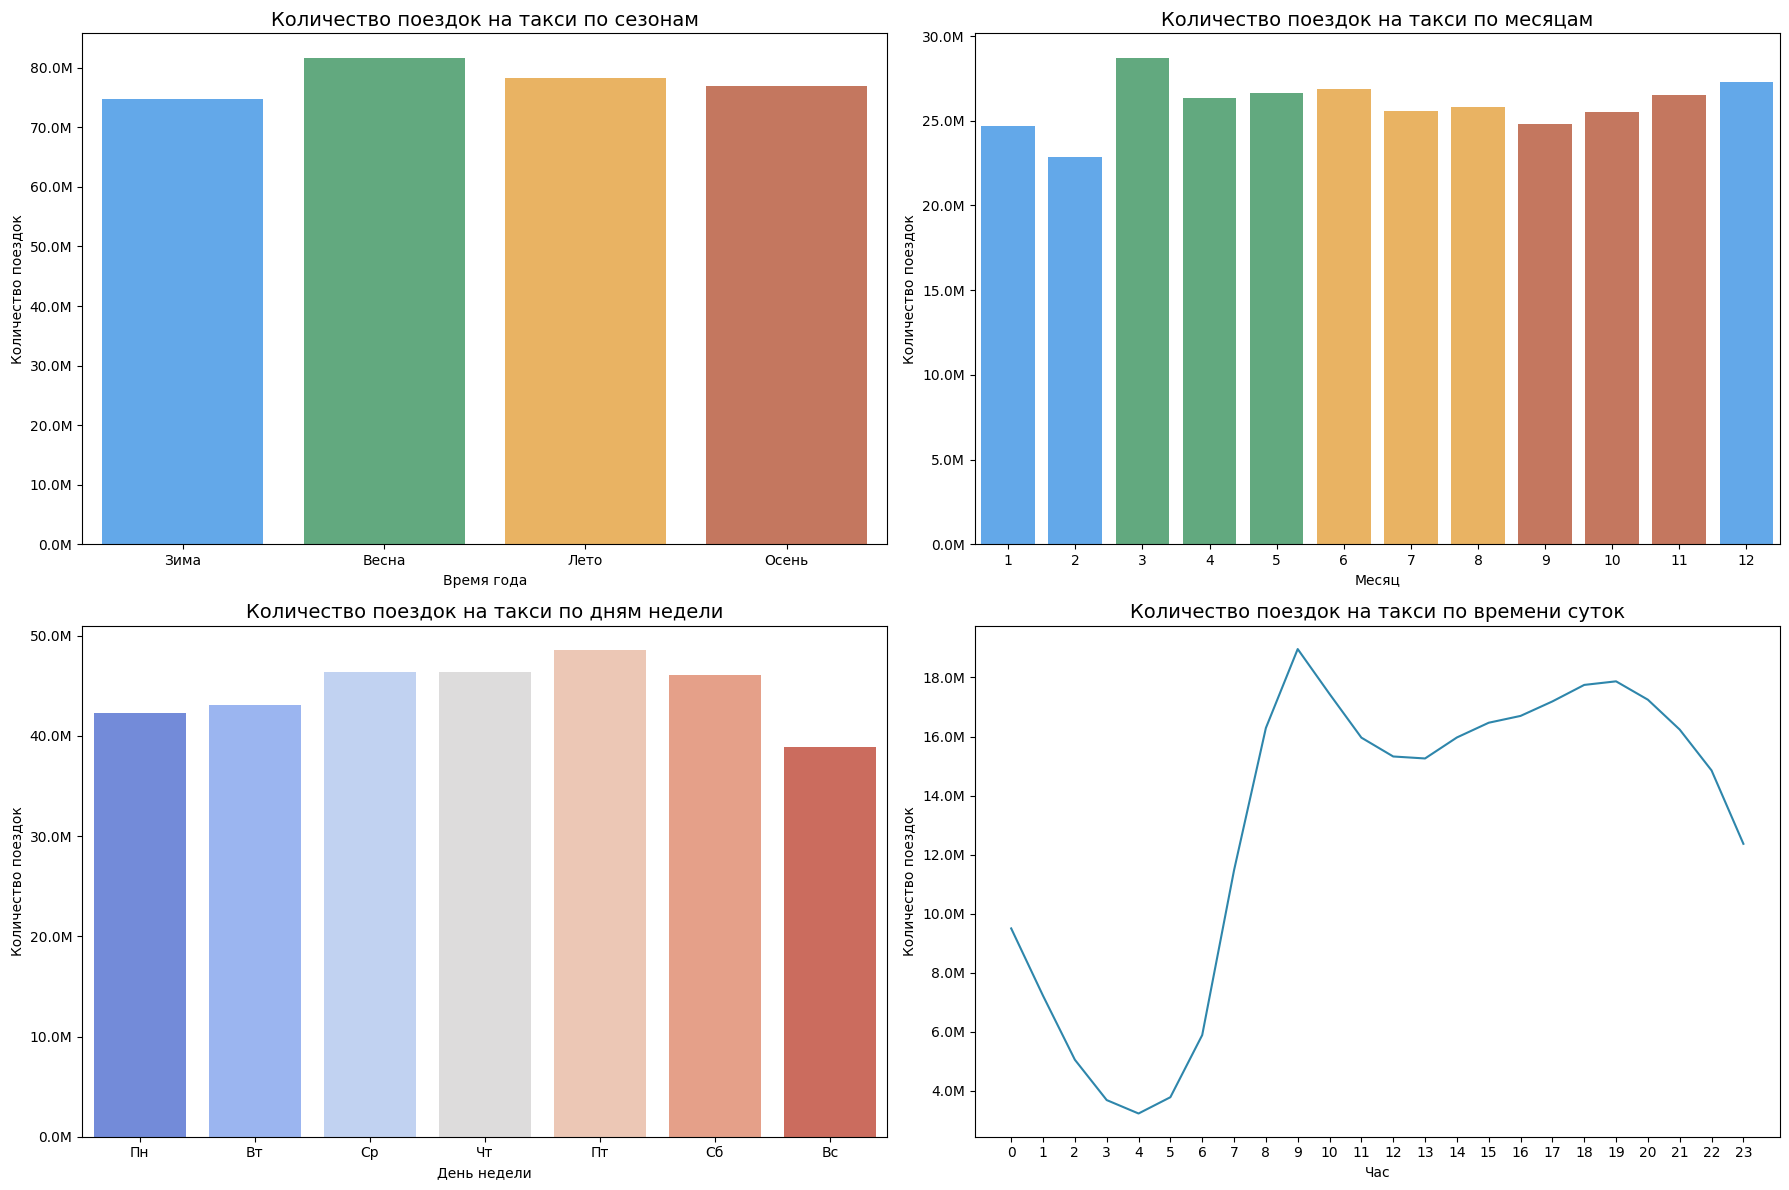

In [28]:
# Создаем subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Функция для форматирования оси Y в миллионы
def millions(x, pos):
    return f'{x / 1e6:.1f}M'

# Цвета для сезонов
season_colors = {
    'Зима': '#4DA9FF',
    'Весна': '#56B57D',
    'Лето': '#FFB84D',
    'Осень': '#D56E4E'
}
season_order = ['Зима', 'Весна', 'Лето', 'Осень']

# График 1: Количество поездок по сезонам
sns.barplot(
    data=rides_by_season,
    x='season',
    y='n_taxi_start',
    order=season_order,
    palette=[season_colors[season] for season in season_order],
    ax=axes[0, 0]
)
axes[0, 0].set_title('Количество поездок на такси по сезонам', fontsize=14)
axes[0, 0].set_xlabel('Время года')
axes[0, 0].set_ylabel('Количество поездок')
axes[0, 0].yaxis.set_major_formatter(FuncFormatter(millions))

# График 2: Количество поездок по месяцам
sns.barplot(
    data=rides_by_month,
    x='month',
    y='n_taxi_start',
    hue='season',
    palette=season_colors,
    ax=axes[0, 1]
)
axes[0, 1].set_title('Количество поездок на такси по месяцам', fontsize=14)
axes[0, 1].set_xlabel('Месяц')
axes[0, 1].set_ylabel('Количество поездок')
axes[0, 1].yaxis.set_major_formatter(FuncFormatter(millions))
# Убираем легенду
axes[0, 1].legend_.remove()

# График 3: Количество поездок по дням недели
sns.barplot(
    data=rides_by_day,
    x='day_of_week',
    y='n_taxi_start',
    palette="coolwarm",
    ax=axes[1, 0]
)
axes[1, 0].set_title('Количество поездок на такси по дням недели', fontsize=14)
axes[1, 0].set_xlabel('День недели')
axes[1, 0].set_ylabel('Количество поездок')
axes[1, 0].set_xticklabels(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])
axes[1, 0].yaxis.set_major_formatter(FuncFormatter(millions))

# График 4: Количество поездок по времени суток
sns.lineplot(
    data=rides_by_hour,
    x='hour_of_day',
    y='n_taxi_start',
    ax=axes[1, 1],
    color='#2E86AB'
)
axes[1, 1].set_title('Количество поездок на такси по времени суток', fontsize=14)
axes[1, 1].set_xlabel('Час')
axes[1, 1].set_ylabel('Количество поездок')
axes[1, 1].set_xticks(range(0, 24, 1))  # каждый час
axes[1, 1].set_xticklabels([str(i) for i in range(0, 24, 1)])  # только числа
axes[1, 1].yaxis.set_major_formatter(FuncFormatter(millions))

# Компоновка
plt.tight_layout()
plt.show()




Из полученных гарфиков мы видим, что больше всего поездок на такси наблюдается весной и в марте, меньше всего - зимой и в феврале. В зависимости от дня недели, чаще всего пользуются такси в пятницу, реже - в воскресенье. Также сильно прослеживается завимость от пиковых часов - больше всего поездок утром с 8 до 9 и вечером с 18 до 19.

Теперь сделаем аналогичные графики для поездок на каршеринге.

<ipython-input-29-416879223f23>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-29-416879223f23>:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-29-416879223f23>:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])


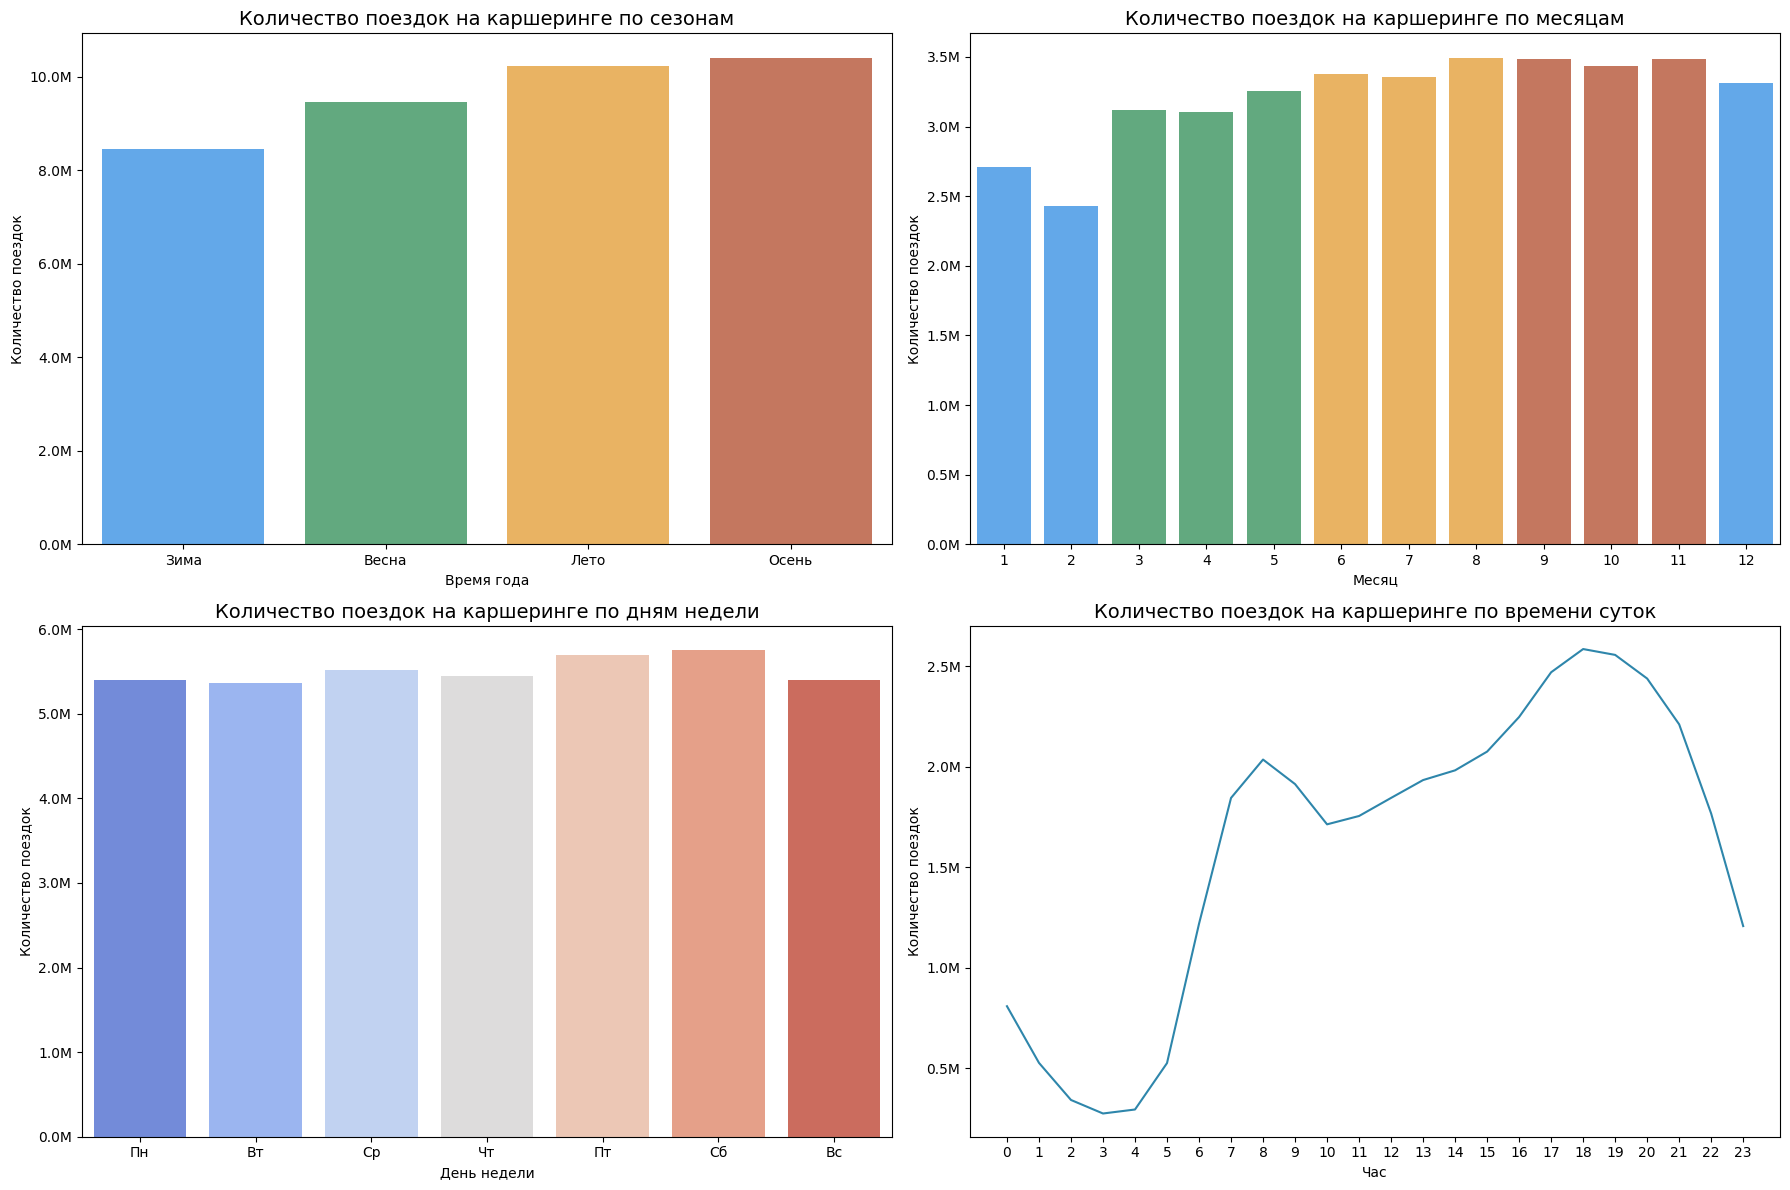

In [29]:
# Считаем агрегации для каршеринга
rides_by_season_cs = main_df.groupby('season')['n_carsharing_start'].sum().reset_index()
rides_by_month_cs = main_df.groupby('month')['n_carsharing_start'].sum().reset_index()
rides_by_month_cs['season'] = main_df.groupby('month')['season'].first().values
rides_by_day_cs = main_df.groupby('day_of_week')['n_carsharing_start'].sum().reset_index()
rides_by_hour_cs = main_df.groupby('hour_of_day')['n_carsharing_start'].sum().reset_index()

# Создаем subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Функция для форматирования оси Y в миллионы
def millions(x, pos):
    return f'{x / 1e6:.1f}M'

# Цвета для сезонов
season_colors = {
    'Зима': '#4DA9FF',
    'Весна': '#56B57D',
    'Лето': '#FFB84D',
    'Осень': '#D56E4E'
}
season_order = ['Зима', 'Весна', 'Лето', 'Осень']

# График 1: Количество поездок по сезонам
sns.barplot(
    data=rides_by_season_cs,
    x='season',
    y='n_carsharing_start',
    order=season_order,
    palette=[season_colors[season] for season in season_order],
    ax=axes[0, 0]
)
axes[0, 0].set_title('Количество поездок на каршеринге по сезонам', fontsize=14)
axes[0, 0].set_xlabel('Время года')
axes[0, 0].set_ylabel('Количество поездок')
axes[0, 0].yaxis.set_major_formatter(FuncFormatter(millions))

# График 2: Количество поездок по месяцам
sns.barplot(
    data=rides_by_month_cs,
    x='month',
    y='n_carsharing_start',
    hue='season',
    palette=season_colors,
    ax=axes[0, 1]
)
axes[0, 1].set_title('Количество поездок на каршеринге по месяцам', fontsize=14)
axes[0, 1].set_xlabel('Месяц')
axes[0, 1].set_ylabel('Количество поездок')
axes[0, 1].yaxis.set_major_formatter(FuncFormatter(millions))
# Убираем легенду
axes[0, 1].legend_.remove()

# График 3: Количество поездок по дням недели
sns.barplot(
    data=rides_by_day_cs,
    x='day_of_week',
    y='n_carsharing_start',
    palette="coolwarm",
    ax=axes[1, 0]
)
axes[1, 0].set_title('Количество поездок на каршеринге по дням недели', fontsize=14)
axes[1, 0].set_xlabel('День недели')
axes[1, 0].set_ylabel('Количество поездок')
axes[1, 0].set_xticklabels(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])
axes[1, 0].yaxis.set_major_formatter(FuncFormatter(millions))

# График 4: Количество поездок по времени суток
sns.lineplot(
    data=rides_by_hour_cs,
    x='hour_of_day',
    y='n_carsharing_start',
    ax=axes[1, 1],
    color='#2E86AB'
)
axes[1, 1].set_title('Количество поездок на каршеринге по времени суток', fontsize=14)
axes[1, 1].set_xlabel('Час')
axes[1, 1].set_ylabel('Количество поездок')
axes[1, 1].set_xticks(range(0, 24, 1))
axes[1, 1].set_xticklabels([str(i) for i in range(0, 24, 1)])
axes[1, 1].yaxis.set_major_formatter(FuncFormatter(millions))

# Компоновка
plt.tight_layout()
plt.show()



Чаще всего каршерингом пользуются осенью и летом, особенно в августе, сентябре и ноябре, реже всего - зимой, в феврале. Сезонность поездок прослеживается сильнее,чем в такси. Частота поездок в пятницу и субботу выше, самая низкая в воскресенье, но в целом распределение по дням недели относительно равномерное. Пик начала поездкок , в отличие от такси, приходится на вечер - с 17 до 19.